#**Understand the Dataset**

In [7]:
import pandas as pd

In [9]:
df = pd.read_csv('/content/cardekho.csv')

In [10]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [11]:
df.shape

(8128, 12)

In [12]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power',
       'seats'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [14]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [15]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),221
engine,221


In [16]:
df.duplicated().sum()

np.int64(1202)

#**DATA CLEANING AND PREPROCESSING**

In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(6926, 12)

In [19]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),208
engine,208


In [21]:
df["max_power"].unique()[:20]

array(['74', '103.52', '78', '90', '88.2', '81.86', '57.5', '37', '67.1',
       '68.1', '108.45', '60', '73.9', nan, '67', '82', '88.5', '46.3',
       '88.73', '64.1'], dtype=object)

In [24]:
df[df["max_power"].apply(lambda x: isinstance(x, str))]["max_power"].unique()

array(['74', '103.52', '78', '90', '88.2', '81.86', '57.5', '37', '67.1',
       '68.1', '108.45', '60', '73.9', '67', '82', '88.5', '46.3',
       '88.73', '64.1', '98.6', '88.8', '83.81', '83.1', '47.3', '73.8',
       '34.2', '35', '81.83', '40.3', '121.3', '138.03', '160.77',
       '117.3', '116.3', '83.14', '67.05', '168.5', '100', '120.7',
       '98.63', '175.56', '103.25', '171.5', '100.6', '174.33', '187.74',
       '170', '78.9', '88.76', '86.8', '108.495', '108.62', '93.7',
       '103.6', '98.59', '189', '67.04', '68.05', '58.2', '82.85', '81.8',
       '73', '120', '94.68', '160', '65', '155', '69.01', '126.32',
       '138.1', '83.8', '126.2', '98.96', '62.1', '86.7', '188', '214.56',
       '177', '280', '148.31', '254.79', '190', '177.46', '204', '141',
       '117.6', '241.4', '282', '150', '147.5', '108.5', '103.5', '183',
       '181.04', '157.7', '164.7', '91.1', '400', '68', '75', '85.8',
       '87.2', '53', '118', '103.2', '83', '84', '58.16', '147.94',
       '

In [25]:
df["max_power"].dtype

dtype('O')

In [29]:
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

df[[
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats"
]].median()

,0
mileage(km/ltr/kg),19.44
engine,1248.00
max_power,81.83
seats,5.00


In [30]:
columns_to_fill = [
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats"
]

for column in columns_to_fill:
    df[column] = df[column].fillna(df[column].median())

In [31]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),0
engine,0


#**EXPLORATORY DATA ANALYSIS**

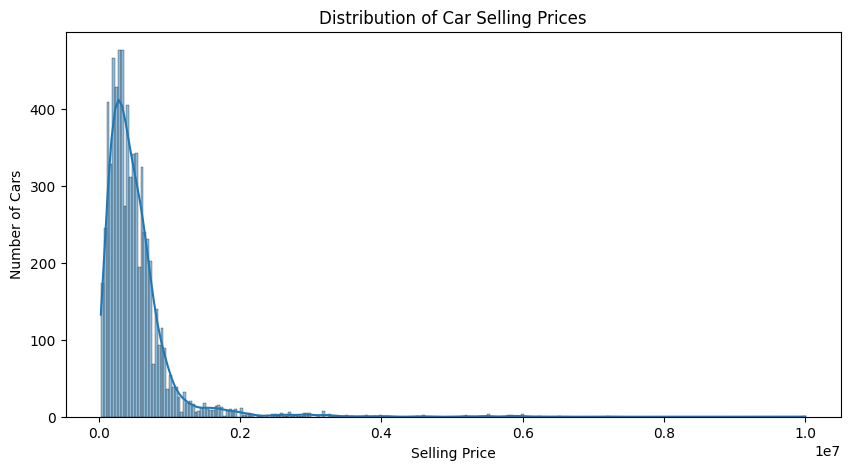

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

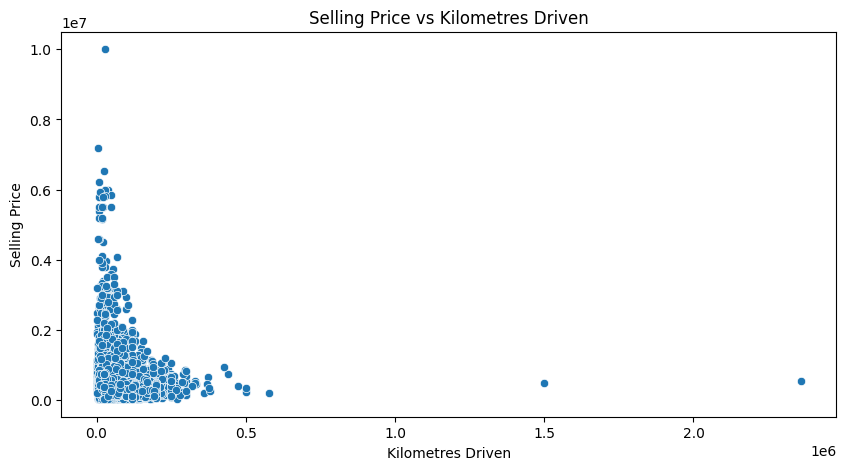

In [32]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="km_driven", y="selling_price")
plt.title("Selling Price vs Kilometres Driven")
plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price")
plt.show()

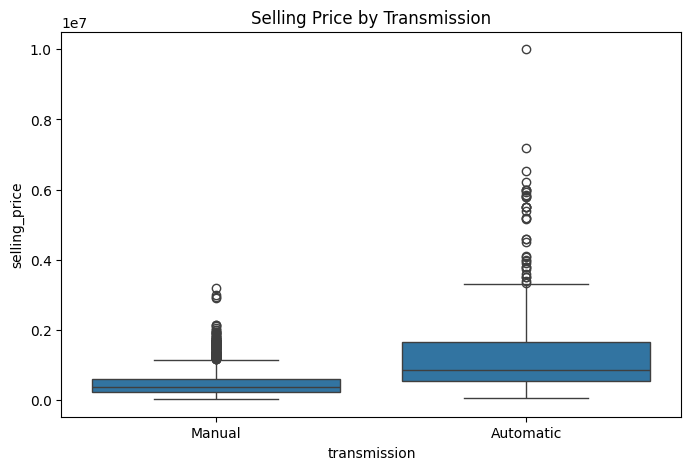

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="transmission", y="selling_price")
plt.title("Selling Price by Transmission")
plt.show()

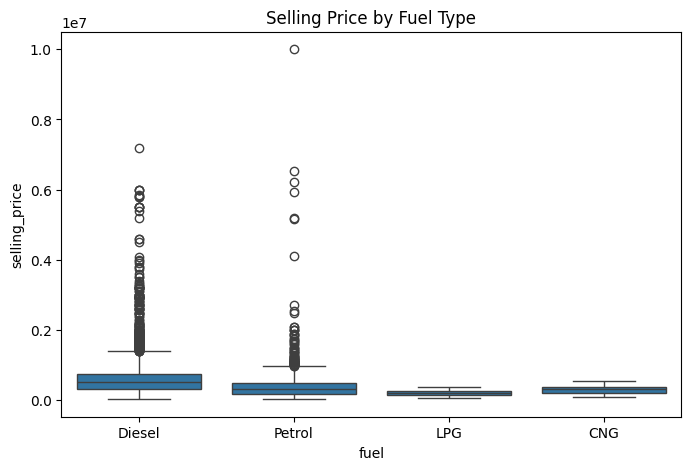

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="fuel", y="selling_price")
plt.title("Selling Price by Fuel Type")
plt.show()

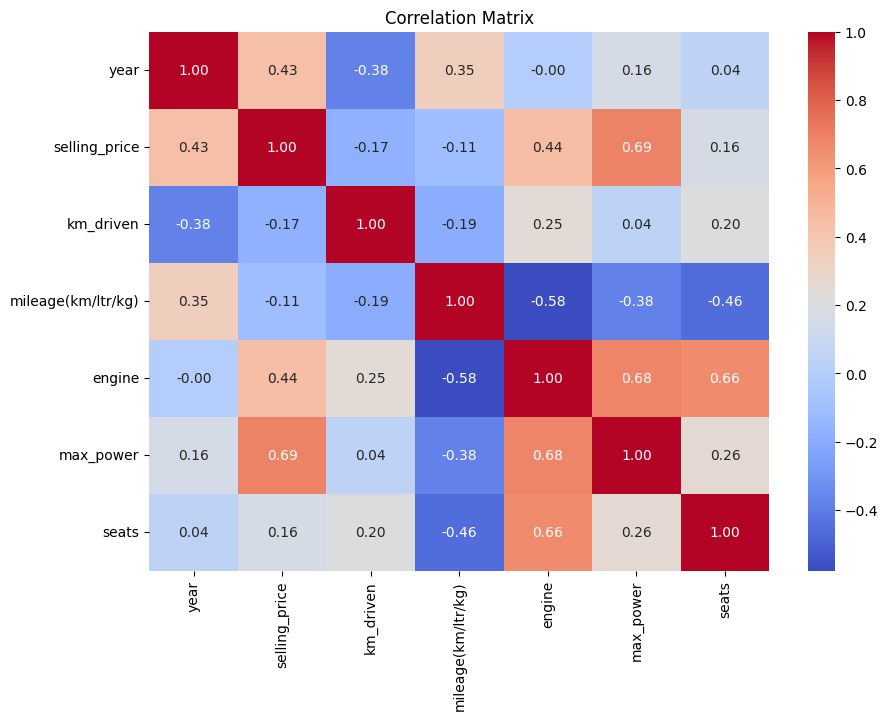

In [38]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

**EDA was performed to understand the distribution of car prices and investigate relationships between vehicle characteristics and selling price.**

In [39]:
X = df.drop(columns=["selling_price", "name"])
y = df["selling_price"]

In [40]:
X.head()

,year,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,2010,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,2007,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [41]:
y.head()

,selling_price
0,450000
1,370000
2,158000
3,225000
4,130000


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5540, 10)
Testing data: (1386, 10)


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = [
    "year",
    "km_driven",
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats"
]

categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#**Build our Model**

#**LINEAR REGRESSION**

In [44]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['year', 'km_driven',
                                                   'mileage(km/ltr/kg)',
                                                   'engine', 'max_power',
                                                   'seats']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['fuel', 'seller_type',
                                                   'transmission',
                                                   'owner'])])),
                ('model', LinearRegression())])

In [45]:
linear_pred = linear_model.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 171632.3519312889
RMSE: 314850.2747742247
R²: 0.5480122209866989


#**RANDOM FOREST**

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['year', 'km_driven',
                                                   'mileage(km/ltr/kg)',
                                                   'engine', 'max_power',
                                                   'seats']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['fuel', 'seller_type',
                                                   'transmission',
                                                   'owner'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [48]:
rf_pred = rf_model.predict(X_test)

In [49]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 75265.4898439898
RMSE: 132542.96965707114
R²: 0.9199001075889979


**Compare the models**

In [50]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,171632.351931,314850.274774,0.548012
1,Random Forest,75265.489844,132542.969657,0.919900


**Based on our comparison, Randon Forest performs better so we will save it**

In [51]:
import joblib

final_model = rf_model

joblib.dump(final_model, "car_price_model.pkl")

['car_price_model.pkl']

In [52]:
import os

print(os.path.getsize("car_price_model.pkl"))

91262995


**Test the saved model**

In [53]:
loaded_model = joblib.load("car_price_model.pkl")

In [54]:
sample_prediction = loaded_model.predict(X_test.iloc[[0]])

print("Predicted price:", sample_prediction[0])
print("Actual price:", y_test.iloc[0])

Predicted price: 713524.99
Actual price: 550000


In [55]:
results

,Model,MAE,RMSE,R2
0,Linear Regression,171632.351931,314850.274774,0.548012
1,Random Forest,75265.489844,132542.969657,0.919900


**"Random Forest Regressor was selected as the final model because it outperformed Linear Regression across MAE, RMSE, and R²."**

In [56]:
import joblib

final_model = rf_model

joblib.dump(final_model, "car_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [57]:
import os

print(os.path.exists("car_price_model.pkl"))

True


In [58]:
from google.colab import files

files.download("car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**app.py**

In [61]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("car_price_model.pkl")

st.set_page_config(
    page_title="Car Price Predictor",
    page_icon="🚗"
)

st.title("🚗 Car Price Prediction App")
st.write("Enter the details of a used car to estimate its selling price.")

year = st.number_input("Manufacturing Year", 1990, 2026, 2018)

km_driven = st.number_input(
    "Kilometres Driven",
    min_value=0,
    max_value=1000000,
    value=50000
)

fuel = st.selectbox(
    "Fuel Type",
    ["Diesel", "Petrol", "CNG", "LPG", "Electric"]
)

seller_type = st.selectbox(
    "Seller Type",
    ["Individual", "Dealer", "Trustmark Dealer"]
)

transmission = st.selectbox(
    "Transmission",
    ["Manual", "Automatic"]
)

owner = st.selectbox(
    "Owner",
    [
        "First Owner",
        "Second Owner",
        "Third Owner",
        "Fourth & Above Owner",
        "Test Drive Car"
    ]
)

mileage = st.number_input(
    "Mileage (km/ltr/kg)",
    min_value=0.0,
    max_value=100.0,
    value=19.44
)

engine = st.number_input(
    "Engine (CC)",
    min_value=0.0,
    max_value=10000.0,
    value=1248.0
)

max_power = st.number_input(
    "Max Power (bhp)",
    min_value=0.0,
    max_value=2000.0,
    value=81.83
)

seats = st.number_input(
    "Number of Seats",
    min_value=1,
    max_value=20,
    value=5
)

if st.button("Predict Car Price"):

    input_data = pd.DataFrame({
        "year": [year],
        "km_driven": [km_driven],
        "fuel": [fuel],
        "seller_type": [seller_type],
        "transmission": [transmission],
        "owner": [owner],
        "mileage(km/ltr/kg)": [mileage],
        "engine": [engine],
        "max_power": [max_power],
        "seats": [seats]
    })

    prediction = model.predict(input_data)[0]

    st.success(f"Estimated Selling Price: ₹{prediction:,.0f}")

Overwriting app.py


In [62]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
joblib

Writing requirements.txt
